# Tacotron2-VAE — Simplified Demo for visualization and debugging



In [1]:
import os
import sys
import json
import time
import glob
from pathlib import Path
from torch.utils.data import DataLoader
from IPython.display import display, clear_output
from tqdm import tqdm

import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "src" / "models" / "tacotron2_vae"))
sys.path.insert(0, str(PROJECT_ROOT / "src" / "training" / "training-tacotron2-vae"))
sys.path.insert(0, str(PROJECT_ROOT / "src" / "data" / "loader_vae_tacotron"))

from models.tacotron2_vae.hparams import create_hparams
from models.tacotron2_vae.model import load_tacotron2_vae_model, get_model_size_info
from losses import Tacotron2LossVAE
from text_processing import TextProcessor
import loader_tacotron
from hparams import Tacotron2VAEHparams
from utils import TextMelCollate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Project root: {PROJECT_ROOT}")

/home/richard/project/ml2_final_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT_DIR: /home/richard/project/ml2_final_project
ROOT_DIR: /home/richard/project/ml2_final_project
Device: cuda
Project root: /home/richard/project/ml2_final_project


In [2]:
processor = TextProcessor()

dataset = loader_tacotron.DatasetLibriSpeechTacotronVAE(text_processor=processor)

print(f"Dataset size: {len(dataset)}")


Dataset size: 38306


In [3]:
hparams = Tacotron2VAEHparams()
model = load_tacotron2_vae_model(hparams, device=device)
criterion = Tacotron2LossVAE(hparams)
optimizer = torch.optim.Adam(model.parameters(), lr=hparams.learning_rate, weight_decay=hparams.weight_decay)

print(get_model_size_info(model))

{'total_params': 28874945, 'trainable_params': 28874945}


[*] Nenhum checkpoint encontrado. Iniciando treino do zero.


Treinando Tacotron2-VAE:   0%|          | 0/100000 [00:00<?, ?it/s]

RuntimeError: The size of tensor a (607) must match the size of tensor b (736) at non-singleton dimension 1

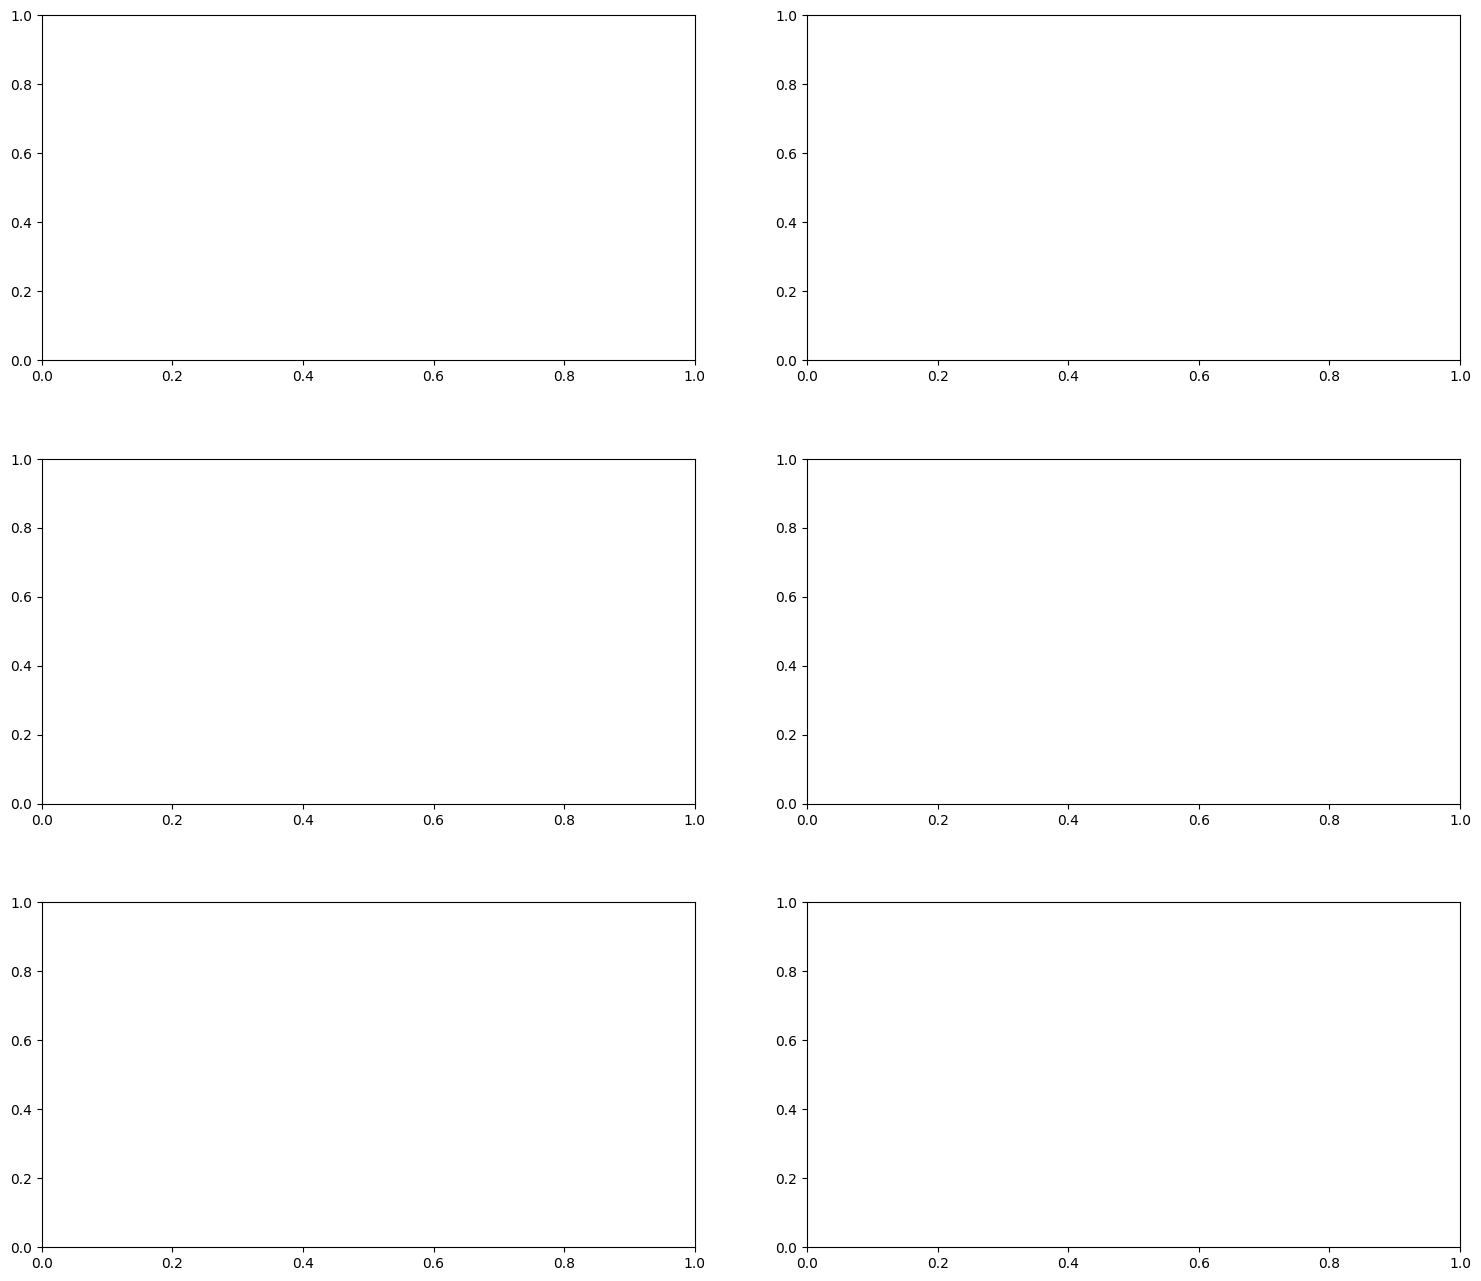

In [4]:
# ==========================================
# 1. SETUP DE DIRETÓRIOS E CHECKPOINTS
# ==========================================
exp_dir = Path("notebooks/experiments/vae_tacotron")
ckpt_dir = exp_dir / "checkpoints"
plots_dir = exp_dir / "plots"
ckpt_dir.mkdir(parents=True, exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)

# Parâmetros
max_steps = 100000
save_interval = 500  # Salva checkpoint e imagem a cada 500 passos
iteration = 0

loss_history, recon_history, kl_history, kl_weight_history = [], [], [], []

# Carregamento do Checkpoint Automático
latest_ckpt = max(glob.glob(str(ckpt_dir / "checkpoint_*.pt")), default=None, key=os.path.getctime)

if latest_ckpt:
    print(f"[*] Checkpoint encontrado! Retomando de: {latest_ckpt}")
    checkpoint = torch.load(latest_ckpt, map_location=device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # scheduler.load_state_dict(checkpoint['scheduler_state_dict']) # Mantido comentado conforme o seu original
    
    iteration = checkpoint['iteration']
    loss_history = checkpoint['history']['loss']
    recon_history = checkpoint['history']['recon']
    kl_history = checkpoint['history']['kl']
    # Usa .get() para evitar erro caso carregue um checkpoint antigo que não tinha o kl_weight
    kl_weight_history = checkpoint['history'].get('kl_weight', []) 
    print(f"[*] Treino retomado a partir do passo {iteration}.")
else:
    print("[*] Nenhum checkpoint encontrado. Iniciando treino do zero.")

# ==========================================
# 2. SETUP DA INTERFACE GRÁFICA (3x2)
# ==========================================
plt.ion()
# Alterado para 3 linhas e 2 colunas para caberem todos os gráficos individuais
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.tight_layout(pad=5.0)

# ==========================================
# 3. LOOP DE TREINAMENTO
# ==========================================
collate_fn = TextMelCollate(hparams.n_frames_per_step)
train_loader = DataLoader(dataset, batch_size=hparams.batch_size, num_workers=0, collate_fn=collate_fn, shuffle=True)

model.train()

# Barra de progresso contínua focada no total de passos
progress_bar = tqdm(total=max_steps, initial=iteration, desc="Treinando Tacotron2-VAE")

while iteration < max_steps:
    for batch in train_loader: 
        if iteration >= max_steps:
            break

        optimizer.zero_grad()
        x, y = model.parse_batch(batch, device)

        # Forward pass
        y_pred = model((x[0], x[1], x[2], x[3], x[4], x[5], x[6]))

        # Cálculo das perdas
        loss, recon_loss, kl_loss, kl_weight = criterion(y_pred, y, iteration)

        # Backward pass
        loss.backward()

        # Monitoramento e Clipping
        parameters = [p for p in model.parameters() if p.grad is not None]
        total_norm = torch.norm(torch.stack([torch.norm(p.grad.detach(), 2.0) for p in parameters]), 2.0)
        torch.nn.utils.clip_grad_norm_(model.parameters(), hparams.grad_clip_thresh)

        # Atualização
        optimizer.step()
        # scheduler.step()

        # Guardando histórico
        loss_history.append(loss.item())
        recon_history.append(recon_loss.item())
        kl_history.append(kl_loss.item())
        kl_weight_history.append(kl_weight)

        current_lr = optimizer.param_groups[0]['lr']
        progress_bar.set_postfix({
            'loss': f"{loss.item():.3f}",
            'kl_w': f"{kl_weight:.4f}",
            'lr': f"{current_lr:.5f}"
        })
        progress_bar.update(1)

        # ==========================================
        # 4. DASHBOARD AO VIVO E PCA (A cada 10 passos)
        # ==========================================
        if iteration % 10 == 0:
            mel_target = y[0][0].data.cpu().numpy()
            mel_predicted = y_pred[1][0].data.cpu().numpy()

            # EXTRAÇÃO DO ESPAÇO LATENTE PARA O PCA
            latent_mu = y_pred[4].detach().cpu() # Shape esperado: (Batch_size, Latent_dim)
            
            # Garante que é 2D (Batch_size, Dim) para o PCA
            if latent_mu.dim() > 2: 
                latent_mu = latent_mu.view(latent_mu.size(0), -1)

            # Calcula o PCA via SVD
            latent_centered = latent_mu - latent_mu.mean(dim=0)
            _, singular_values, _ = torch.linalg.svd(latent_centered, full_matrices=False)
            singular_values = singular_values.numpy()

            # --- LIMPEZA DOS GRÁFICOS ---
            for ax in axes.flat:
                ax.clear()

            # [0, 0]: Mel Alvo
            axes[0, 0].imshow(mel_target, aspect='auto', origin='lower', cmap='magma')
            axes[0, 0].set_title(f"Alvo (Target) | Passo: {iteration}")
            axes[0, 0].set_ylabel("Canais")

            # [0, 1]: Mel Gerado
            axes[0, 1].imshow(mel_predicted, aspect='auto', origin='lower', cmap='magma')
            axes[0, 1].set_title(f"Gerado (Post-Net) | Norm: {total_norm.item():.1f}")

            # [1, 0]: Total Loss
            axes[1, 0].plot(loss_history, color='blue', alpha=0.8)
            axes[1, 0].set_title("Total Loss")
            axes[1, 0].set_xlabel("Passos")
            axes[1, 0].set_ylabel("Loss")
            axes[1, 0].grid(True, linestyle='--', alpha=0.5)

            # [1, 1]: Recon Loss
            axes[1, 1].plot(recon_history, color='green', alpha=0.8)
            axes[1, 1].set_title("Reconstruction Loss")
            axes[1, 1].set_xlabel("Passos")
            axes[1, 1].set_ylabel("Loss")
            axes[1, 1].grid(True, linestyle='--', alpha=0.5)

            # [2, 0]: KL Loss
            axes[2, 0].plot(kl_history, color='red', alpha=0.8)
            axes[2, 0].set_title("KL Loss")
            axes[2, 0].set_xlabel("Passos")
            axes[2, 0].set_ylabel("Loss")
            axes[2, 0].grid(True, linestyle='--', alpha=0.5)

            # [2, 1]: PCA / Valores Singulares
            axes[2, 1].bar(range(1, len(singular_values) + 1), singular_values, color='purple')
            axes[2, 1].set_title("PCA: Valores Singulares do Espaço Latente (Batch)")
            axes[2, 1].set_xlabel("Componente Principal")
            axes[2, 1].set_ylabel("Variância (S)")

            clear_output(wait=True)
            display(fig)

        # ==========================================
        # 5. SALVAMENTO DE CHECKPOINT
        # ==========================================
        if iteration > 0 and iteration % save_interval == 0:
            ckpt_path = ckpt_dir / f"checkpoint_{iteration}.pt"
            plot_path = plots_dir / f"plot_{iteration}.png"
            
            # Salva Pesos e Histórico (agora incluindo o kl_weight)
            torch.save({
                'iteration': iteration,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
              # 'scheduler_state_dict': scheduler.state_dict(),
                'history': {
                    'loss': loss_history,
                    'recon': recon_history,
                    'kl': kl_history,
                    'kl_weight': kl_weight_history
                }
            }, ckpt_path)
            
            # Salva o gráfico atual completo (3x2)
            fig.savefig(plot_path)

        iteration += 1

progress_bar.close()
plt.ioff()
plt.close(fig)
print("\n[✔] Treinamento avançado finalizado!")